In [1]:
import sys
from pathlib import Path
################################################################
src_path = Path().resolve().parent / "src"
sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt
import numpy as np
from data_io import get_summary_data
from plotting import plot_group_mean_psth, generate_heatmaps 
from analysis import generate_nan_free_z_score, get_max_rate_dict
import dabest_helper as dbh

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 24.15it/s]


Numba compilation complete!


In [2]:
sys.path

['/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src',
 '/usr/lib/python310.zip',
 '/usr/lib/python3.10',
 '/usr/lib/python3.10/lib-dynload',
 '',
 '/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/venv/lib/python3.10/site-packages']

In [3]:
##################################################################################################################
path_to_dir = '/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/data/group_ifr/'
#################################################################################################################
ctype_list = ['pdg','p3','p1']
file_ext = '.npy'

okey_list = ['ds','swr','ds1','ds2']

ctype_dict = {'pdg':'DG',
              'p3':'CA3',
              'p1':'CA1',
             }
##################################################################################################################
all_summary_data = {}
for indx,okey in enumerate(okey_list):
    ipath = path_to_dir + okey
    temp_dat = get_summary_data(ipath,ctype_list,file_ext,pprint=False) 
    all_summary_data[okey] = temp_dat
###################################################################################################################

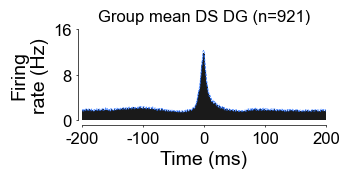

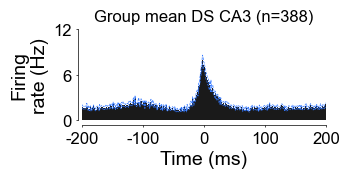

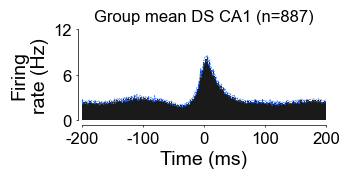

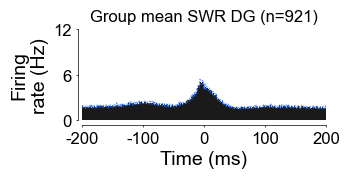

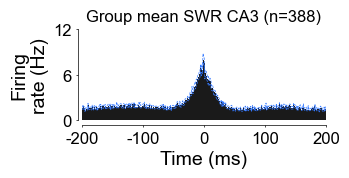

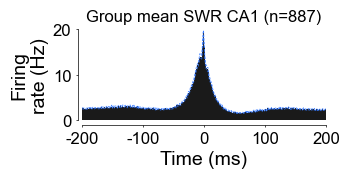

In [4]:
##################################################################################################################
event_type_list = ['ds','swr']

for event_indx,event_type in enumerate(event_type_list):
    for cindx,ctype in enumerate(ctype_list):
        fig,ax = plot_group_mean_psth(all_summary_data,event_type,ctype,size_scale=2,fwd=4,fht=1.5,err_bars=True,savgol=False)
        plt.show()
###############################################################################################################################

In [5]:
zscore_dat = generate_nan_free_z_score(all_summary_data,okey_list=ctype_list,ikey_list=event_type_list)

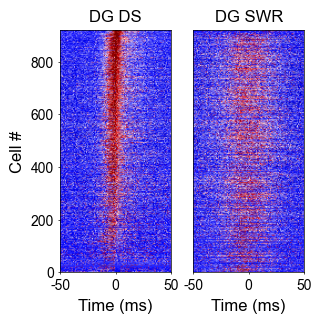

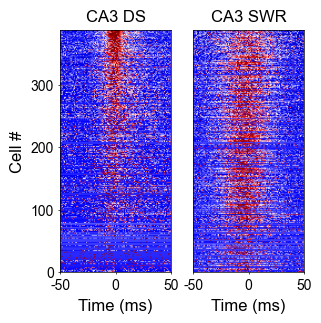

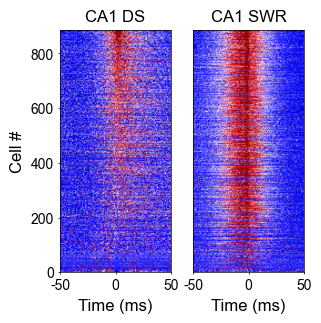

In [6]:
##############################################################################
# Figure 1G, Figure 2F
##############################################################################
cmap = 'seismic'
zscore_dat = generate_nan_free_z_score(all_summary_data,okey_list=ctype_list,ikey_list=event_type_list)

for cindx,ctype in enumerate(ctype_list):
    fig,ax = generate_heatmaps(zscore_dat,
                               ctype,
                               event_type_list,
                               size_scale=2,
                               sort_event=event_type_list[0],
                               ctype_dict=ctype_dict, 
                               cmap=cmap,
                               vmin=-2,
                               vmax_dict={'ds':4, 'swr':4, 'ds1':4, 'ds2':4},
                               interpolation='auto',
                               origin='lower'
                              )

In [7]:
####################################################################################################
# Figure 2g
####################################################################################################
idata = get_max_rate_dict(all_summary_data,ctype_list)

outerkey = ['baseline','ds1','ds2','ds','swr']
innerkey = ctype_list
col_head = ['id','Event_Type','Cell_Type','Data','Cell_Event']
col_groups = {
              'pdg':'pdg',
              'p3':'p3',
              'p1':'p1',
             }
####################################################################################################
df_idx = [
            ['pdg_baseline','pdg_ds','pdg_ds1','pdg_ds2','pdg_swr'],
            ['p3_baseline', 'p3_ds','p3_ds1','p3_ds2','p3_swr'],
            ['p1_baseline', 'p1_ds','p1_ds1','p1_ds2','p1_swr']
         ]
####################################################################################################
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Cell_Event',
                                                   y='Data')
####################################################################################################

pdg_baseline
pdg_ds1
pdg_ds2
pdg_ds
pdg_swr
p3_baseline
p3_ds1
p3_ds2
p3_ds
p3_swr
p1_baseline
p1_ds1
p1_ds2
p1_ds
p1_swr
10960
10960


/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:28: RuntimeWarning: Mean of empty slice
  tempdict[ctype] = np.nanmean(tempdat[xrange[0]:xrange[1]],axis=0)


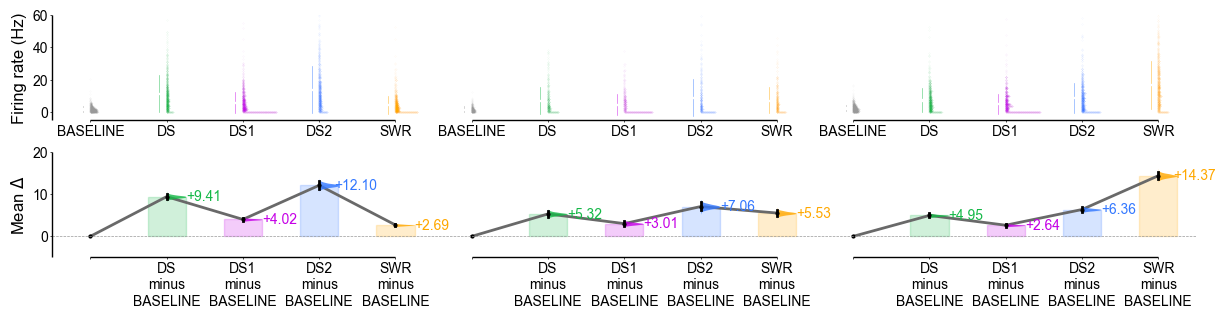

In [8]:
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                           df_idx,
                                                           show_pairs=False,
                                                           diff_type='mean',
                                                           swlab='Firing rate (Hz)',
                                                           size_scale=2,
                                                           fwd=1.25,
                                                           fht=4,
                                                           pad=1.5,
                                                           swarm_ylim=(-5,60),
                                                           contrast_ylim=(-5,20),
                                                           swarm_maj_loc=20,
                                                           contrast_maj_loc=10,
                                                           fscale=(5,6,7),
                                                           raw_marker_size=0.002,
                                                           #jitter=8,
                                                           my_color_palette=None)

swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=1,upper_case=True)
plt.show()

In [9]:
########################################################################################################
analysis_of_long_df.mean_diff.statistical_tests
########################################################################################################

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,pdg_baseline,pdg_ds,917,917,mean difference,baseline,9.411684,95,8.795687,10.130379,0.0,1.367030e-146,3241.0,2.993864e-125,-28.017480
1,pdg_baseline,pdg_ds1,917,917,mean difference,baseline,4.015148,95,3.647834,4.382549,0.0,7.346931e-95,43368.0,7.378846e-85,-21.744781
2,pdg_baseline,pdg_ds2,917,917,mean difference,baseline,12.095522,95,11.290869,13.035739,0.0,3.832975e-146,3560.0,2.778160e-123,-27.717465
3,pdg_baseline,pdg_swr,917,917,mean difference,baseline,2.686408,95,2.409391,3.007891,0.0,2.072979e-92,45732.0,9.945391e-61,-17.735689
4,p3_baseline,p3_ds,388,388,mean difference,baseline,5.317940,95,4.666540,6.057902,0.0,1.343046e-49,4407.0,1.954932e-40,-15.004285
5,p3_baseline,p3_ds1,388,388,mean difference,baseline,3.014657,95,2.527641,3.591571,0.0,3.704560e-20,16491.0,3.619751e-24,-10.861802
6,p3_baseline,p3_ds2,388,388,mean difference,baseline,7.062891,95,6.143423,8.176420,0.0,5.012406e-44,6377.0,2.920923e-34,-13.489567
7,p3_baseline,p3_swr,388,388,mean difference,baseline,5.529940,95,4.860782,6.344329,0.0,5.506692e-50,4738.0,4.746722e-38,-14.424800
8,p1_baseline,p1_ds,887,887,mean difference,baseline,4.953813,95,4.584963,5.420224,0.0,2.083425e-125,13896.5,1.575658e-94,-23.377708
9,p1_baseline,p1_ds1,887,887,mean difference,baseline,2.637325,95,2.314129,2.984116,0.0,6.183047e-47,84539.5,1.753872e-46,-15.189183


In [ ]:
### stop here